# Modeling: Daily CA Energy Load Prediction

This notebook trains and evaluates several regression models to predict daily California energy load. It uses the processed train, validation, and test sets created in the preprocessing notebook.

The final goal is to save a single fitted pipeline artifact that can later be loaded into a Streamlit app and used with weather data from the OpenWeatherMap API.

In [3]:
import pandas as pd
import numpy as np
import joblib

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [5]:
# Load processed feature and target splits
X_train = pd.read_csv("../data/processed/X_train_daily.csv")
X_val = pd.read_csv("../data/processed/X_val_daily.csv")
X_test = pd.read_csv("../data/processed/X_test_daily.csv")

y_train = pd.read_csv("../data/processed/y_train_daily.csv").squeeze("columns")
y_val = pd.read_csv("../data/processed/y_val_daily.csv").squeeze("columns")
y_test = pd.read_csv("../data/processed/y_test_daily.csv").squeeze("columns")

print("X_train:", X_train.shape)
print("X_val:", X_val.shape)
print("X_test:", X_test.shape)

print("y_train:", y_train.shape)
print("y_val:", y_val.shape)
print("y_test:", y_test.shape)

X_train: (255, 47)
X_val: (55, 47)
X_test: (55, 47)
y_train: (255,)
y_val: (55,)
y_test: (55,)


In [6]:
# Identify numeric and categorical columns
categorical_cols = X_train.select_dtypes(include=["object", "category"]).columns.tolist()
numeric_cols = X_train.select_dtypes(include=[np.number]).columns.tolist()

print("Categorical columns:")
print(categorical_cols)

print("\nNumeric columns:")
print(numeric_cols)

Categorical columns:
['day_name']

Numeric columns:
['la_temp_mean', 'la_temp_max', 'la_temp_min', 'la_temp_std', 'la_rhum_mean', 'la_rhum_max', 'la_rhum_min', 'la_rhum_std', 'la_prcp_sum', 'la_prcp_max', 'la_wspd_mean', 'la_wspd_max', 'la_wspd_std', 'sf_temp_mean', 'sf_temp_max', 'sf_temp_min', 'sf_temp_std', 'sf_rhum_mean', 'sf_rhum_max', 'sf_rhum_min', 'sf_rhum_std', 'sf_prcp_sum', 'sf_prcp_max', 'sf_wspd_mean', 'sf_wspd_max', 'sf_wspd_std', 'sd_temp_mean', 'sd_temp_max', 'sd_temp_min', 'sd_temp_std', 'sd_rhum_mean', 'sd_rhum_max', 'sd_rhum_min', 'sd_rhum_std', 'sd_prcp_sum', 'sd_prcp_max', 'sd_wspd_mean', 'sd_wspd_max', 'sd_wspd_std', 'is_weekend', 'month_sin', 'month_cos', 'day_of_week_sin', 'day_of_week_cos', 'day_of_year_sin', 'day_of_year_cos']


/var/folders/r0/mxnnbvln7wl__9w60hwgw01c0000gn/T/ipykernel_72722/1514578731.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = X_train.select_dtypes(include=["object", "category"]).columns.tolist()


In [7]:
# Build preprocessing transformer
preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numeric_cols),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_cols)
    ]
)

In [8]:
# Define evaluation function
def evaluate_regression(y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_true, y_pred)

    return {
        "MAE": mae,
        "RMSE": rmse,
        "R2": r2
    }

In [9]:
# Define candidate models
models = {
    "LinearRegression": LinearRegression(),
    "Ridge": Ridge(alpha=1.0),
    "RandomForest": RandomForestRegressor(
        n_estimators=300,
        random_state=42
    ),
    "GradientBoosting": GradientBoostingRegressor(
        n_estimators=300,
        learning_rate=0.05,
        max_depth=3,
        random_state=42
    )
}

In [10]:
# Train each pipeline and evaluate on validation set
results = []
fitted_pipelines = {}

for model_name, model in models.items():
    pipeline = Pipeline([
        ("preprocessor", preprocessor),
        ("model", model)
    ])

    pipeline.fit(X_train, y_train)
    val_preds = pipeline.predict(X_val)

    metrics = evaluate_regression(y_val, val_preds)
    metrics["Model"] = model_name

    results.append(metrics)
    fitted_pipelines[model_name] = pipeline

In [11]:
# Compare validation results
results_df = pd.DataFrame(results).sort_values("RMSE").reset_index(drop=True)
results_df

,MAE,RMSE,R2,Model
0,1725.636736,2023.620897,0.403864,GradientBoosting
1,1677.315579,2037.914235,0.395413,RandomForest
2,4366.572750,4639.656170,-2.133707,Ridge
3,4399.668445,4669.507282,-2.174161,LinearRegression


In [12]:
# GradientBoosting had the lowest validation RMSE, so I selected it as the final model.
# RandomForest was very close, but GradientBoosting handled larger errors slightly better.

best_model_name = "GradientBoosting"
best_pipeline = fitted_pipelines[best_model_name]

print("Selected model:", best_model_name)

Selected model: GradientBoosting


In [13]:
# Show validation metrics for the selected model
val_preds = best_pipeline.predict(X_val)
val_metrics = evaluate_regression(y_val, val_preds)

print("Validation metrics for selected model:")
for metric_name, value in val_metrics.items():
    print(f"{metric_name}: {value:,.3f}")

Validation metrics for selected model:
MAE: 1,725.637
RMSE: 2,023.621
R2: 0.404


In [14]:
# Combine train and validation sets for final training
X_train_full = pd.concat([X_train, X_val], axis=0).reset_index(drop=True)
y_train_full = pd.concat([y_train, y_val], axis=0).reset_index(drop=True)

print("X_train_full:", X_train_full.shape)
print("y_train_full:", y_train_full.shape)

X_train_full: (310, 47)
y_train_full: (310,)


In [15]:
# Rebuild and fit the final pipeline using GradientBoosting
final_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", GradientBoostingRegressor(
        n_estimators=300,
        learning_rate=0.05,
        max_depth=3,
        random_state=42
    ))
])

final_pipeline.fit(X_train_full, y_train_full)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers co

In [16]:
# Evaluate final model on the test set
test_preds = final_pipeline.predict(X_test)
test_metrics = evaluate_regression(y_test, test_preds)

print("Test metrics for final model:")
for metric_name, value in test_metrics.items():
    print(f"{metric_name}: {value:,.3f}")

Test metrics for final model:
MAE: 1,086.971
RMSE: 1,308.599
R2: 0.001


In [17]:
# Summarize validation and test performance
final_summary = pd.DataFrame([{
    "Selected_Model": best_model_name,
    "Validation_MAE": val_metrics["MAE"],
    "Validation_RMSE": val_metrics["RMSE"],
    "Validation_R2": val_metrics["R2"],
    "Test_MAE": test_metrics["MAE"],
    "Test_RMSE": test_metrics["RMSE"],
    "Test_R2": test_metrics["R2"]
}])

final_summary

,Selected_Model,Validation_MAE,Validation_RMSE,Validation_R2,Test_MAE,Test_RMSE,Test_R2
0,GradientBoosting,1725.636736,2023.620897,0.403864,1086.971223,1308.598702,0.001263


In [18]:
# Inspect a sample of predictions
pred_comparison = pd.DataFrame({
    "actual": y_test,
    "predicted": test_preds,
    "error": y_test - test_preds,
    "abs_error": np.abs(y_test - test_preds)
})

pred_comparison.head(10)

,actual,predicted,error,abs_error
0,25212.670066,24600.952490,611.717576,611.717576
1,23614.489720,22525.040709,1089.449012,1089.449012
2,23265.185960,22637.854907,627.331053,627.331053
3,25770.464043,24855.768353,914.695689,914.695689
4,25313.162427,24554.894316,758.268111,758.268111
5,25323.415209,24999.572278,323.842931,323.842931
6,25195.323255,25105.734226,89.589029,89.589029
7,24430.487712,25537.218879,-1106.731167,1106.731167
8,22789.653171,23302.572864,-512.919694,512.919694
9,22386.366687,23198.698148,-812.331460,812.331460


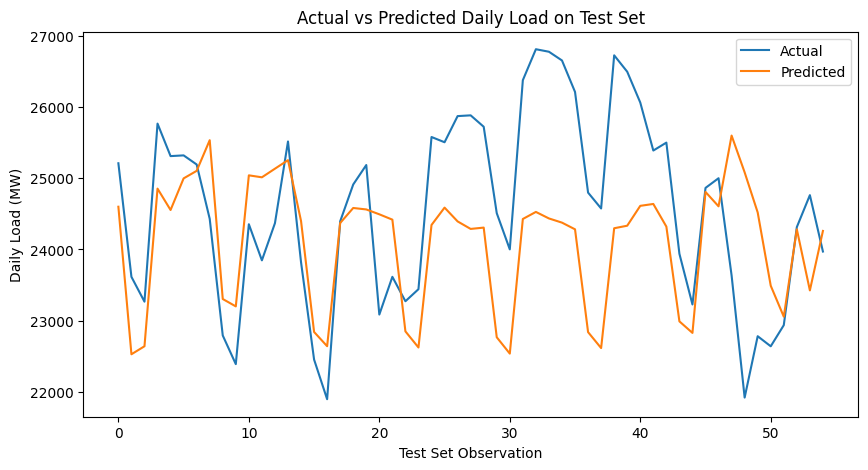

In [19]:
# Plot actual vs predicted values for the test set
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))
plt.plot(y_test.reset_index(drop=True), label="Actual")
plt.plot(pd.Series(test_preds), label="Predicted")
plt.title("Actual vs Predicted Daily Load on Test Set")
plt.xlabel("Test Set Observation")
plt.ylabel("Daily Load (MW)")
plt.legend()
plt.show()

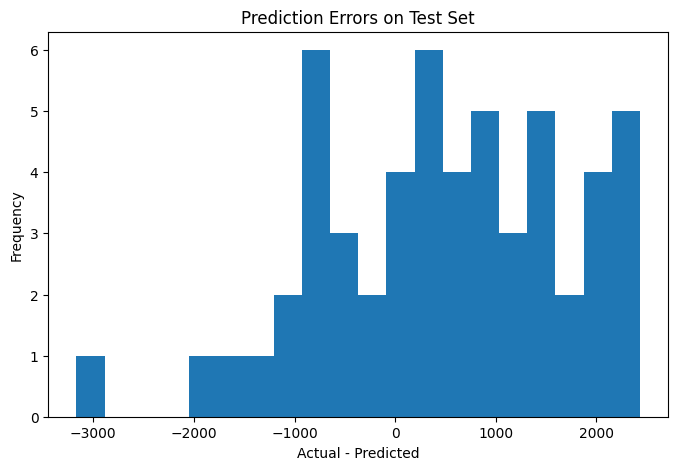

In [20]:
# Plot prediction error distribution
plt.figure(figsize=(8, 5))
plt.hist(y_test - test_preds, bins=20)
plt.title("Prediction Errors on Test Set")
plt.xlabel("Actual - Predicted")
plt.ylabel("Frequency")
plt.show()

In [21]:
# Save final trained pipeline
artifact_path = "../data/artifacts/gradientboosting_daily_pipeline.pkl"
joblib.dump(final_pipeline, artifact_path)

print("Saved pipeline to:", artifact_path)

Saved pipeline to: ../data/artifacts/gradientboosting_daily_pipeline.pkl


In [22]:
# Save metadata for future app use
model_metadata = {
    "best_model_name": best_model_name,
    "feature_columns": X_train.columns.tolist(),
    "numeric_columns": numeric_cols,
    "categorical_columns": categorical_cols,
    "target_column": "target_load_mw_mean"
}

metadata_path = "../data/artifacts/daily_model_metadata.pkl"
joblib.dump(model_metadata, metadata_path)

print("Saved metadata to:", metadata_path)

Saved metadata to: ../data/artifacts/daily_model_metadata.pkl


In [23]:
# Quick load test
loaded_pipeline = joblib.load(artifact_path)

sample_input = X_test.head(3).copy()
sample_preds = loaded_pipeline.predict(sample_input)

print("Sample predictions from loaded pipeline:")
print(sample_preds)

Sample predictions from loaded pipeline:
[24600.95248976 22525.04070859 22637.8549069 ]
